## Working File to Test and Run Code Segments

# Function to change image resolution to desired size


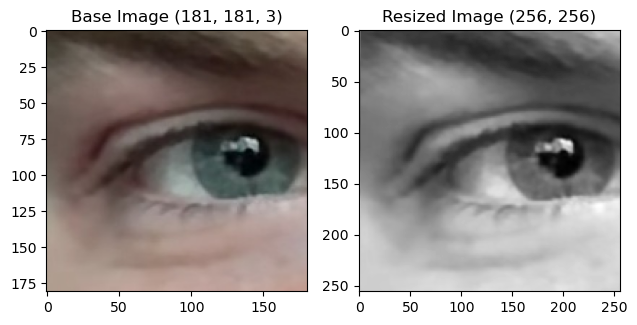

In [32]:
import numpy 
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

def blur_and_sample(img, a=0.4):
    # Enter your code here
    
    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(img, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # initialize new photo
    nRows = int(numpy.ceil(img.shape[0] / 2))
    nCols = int(numpy.ceil(img.shape[1] / 2))
    downsampled_img = numpy.zeros([nRows, nCols])

    # sample pixels for the downsampled image
    for row in range(0, nRows):
        for col in range(0, nCols):
            bRow = row*2
            bCol = col*2
            downsampled_img[row, col] = numpy.mean(blurred[bRow:bRow+1, bCol:bCol+1])
    
    return downsampled_img

def sharpen(img):
    # Enter your code here
    
    # initialize new photo
    nRows = int(img.shape[0] * 2 - 1)
    nCols = int(img.shape[1] * 2 - 1)
    upsampled_img = numpy.zeros([nRows, nCols])
    
    # assign odd (even index) row,col values to correspond to known values
    for row in range(0, nRows, 2):
        for col in range(0, nCols, 2):
            upsampled_img[row, col] = img[int(row/2)-1, int(col/2)-1]

    # assign even (odd index) row,col values using interpolation
    for row in range(1, nRows, 2):
        for col in range(1, nCols, 2):
            inputRow = int((row - 1) / 2)
            inputCol = int((col - 1)/ 2)
            upsampled_img[row, col] = numpy.mean(img[inputRow:inputRow+1, inputCol:inputCol+1])

    return upsampled_img

def downsample_to_ideal(image, ideal_shape = [256,256], a=0.4):
# Function that an image as an input and updates the resolution of each image to make the ideal shape. 
# Uses downsampling to decrease resolution
# Inputs:
#   image: A square image that is larger or equal to the ideal_shape image, but not more than twice the size
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_image: The image resized to the ideal_shape


    # initialize new photo
    resized_image = numpy.zeros(ideal_shape)

    # scaling factor
    scale_factor = ideal_shape[0] / image.shape[0]
    # print(scale_factor)

    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(image, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # downsample to fill the photo
    for row in range(0, ideal_shape[0]):
        for col in range(0, ideal_shape[1]):

            # translate row and col number to original image
            original_row = row / scale_factor
            original_row_rounded = int(round(original_row, 0))
            original_row_rerror = original_row - original_row_rounded

            original_col = col / scale_factor
            original_col_rounded = int(round(original_col, 0))
            original_col_rerror = original_col - original_col_rounded

            # take gaussian average based on distance from actual value: 
            resized_image[row, col] = blurred[original_row_rounded, original_col_rounded]

    return resized_image



def change_resolution(image, ideal_shape = [256,256], testing=False):
# Function that takes an array of images as an input and updates the resolution of each image to make the ideal shape. 
# Uses blurring or reverse blurring/sharpening to decrease and increase resolution (respectively)
# Inputs:
#   images: An array of images
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_images: The image array where each image has been resized to the ideal_shape

    # first, reduce to grayscale
    resized_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # while loop to determine if image is correct size
    flag = True
    while(flag):
        if resized_image.shape[0] > ideal_shape[0] * 2: # if image is too large, blur and downsample
            if testing:
                print('Blurring')
            resized_image = blur_and_sample(resized_image)
        elif resized_image.shape[0] < ideal_shape[0]: # if image is too small, sharpen/interpolated it
            resized_image = sharpen(resized_image)
            if testing:
                print("Sharpening")
        else:
            resized_image = downsample_to_ideal(resized_image, ideal_shape)
            flag = False

    return resized_image

image = cv2.imread('./frame_0005_left_eye.jpg')
corrected_image = numpy.zeros_like(image)
corrected_image[:,:,0] = image[:,:,2]
corrected_image[:,:,1] = image[:,:,1]
corrected_image[:,:,2] = image[:,:,0]

resized_image = change_resolution(image, [256,256])

fig, ax = plt.subplots(1,2)
ax[0].imshow(corrected_image)
ax[0].set_title(f"Base Image {image.shape}")
ax[1].imshow(resized_image, cmap='gray')
ax[1].set_title(f"Resized Image {resized_image.shape}")
plt.tight_layout()